In [71]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('../logisticReg/iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [65]:
filtered_df = df[df['Species'].isin(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])].copy()
filtered_df['Species'] = filtered_df['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

In [68]:
features = filtered_df[['PetalLengthCm', 'PetalWidthCm']]
X = features.values
y = Y = filtered_df['Species'].to_numpy(dtype=np.int64)

In [36]:
def normalize(X):
    print("Mean Before: ", X.mean(axis=0), "\nStd dev. Before: ", X.std(axis=0))

    sc = StandardScaler()
    XScaled = sc.fit_transform(X)

    print("Mean After: ", XScaled.mean(axis=0), "\nStd dev. After: ",XScaled.std(axis=0))
    return XScaled

In [49]:
X_scaled = normalize(X)
pca = PCA(n_components=2)
X_pcaed = pca.fit_transform(X_scaled)
    

Mean Before:  [3.75866667 1.19866667] 
Std dev. Before:  [1.75852918 0.76061262]
Mean After:  [ 3.31586610e-16 -2.84217094e-16] 
Std dev. After:  [1. 1.]


In [78]:
def Kmeans_agglo(X_pcaed, n_clusters=3):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    agglo = AgglomerativeClustering(n_clusters=n_clusters)
    agglo.fit_predict(X_pcaed)
    kmeans.fit_predict(X_pcaed)
    kMeansLabels = kmeans.labels_
    aggloLabels = agglo.labels_
    kMeandCentroids = kmeans.cluster_centers_
    kMeansInertia = kmeans.inertia_

    print("\n--------------------------------------------------------------\n")

    print("K-means Cluster Centers (Centroids):\n", kMeandCentroids)
    print("\nK-means Inertia (Sum of squared distances to centroids):", kMeansInertia)
    print("\nK-means Cluster Labels for Each Point:", kMeansLabels)

    print("\n--------------------------------------------------------------\n")
    print("\nAgglomerative Clustering Cluster Labels for Each Point:", aggloLabels)

    # Visualize the clusters
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].scatter(X_pcaed[:, 0], X_pcaed[:, 1], c=kMeansLabels,
    cmap='viridis')
    axes[0].set_title("Iris - KMeans Clustering")

    axes[1].scatter(X_pcaed[:, 0], X_pcaed[:, 1], c=aggloLabels, cmap='plasma')
    axes[1].set_title("Iris - Agglomerative Clustering")


    axes[2].scatter(X_pcaed[:, 0], X_pcaed[:, 1], c=y,
    cmap='Set1')
    axes[2].set_title("Iris - Actual Labels")
    plt.tight_layout()
    plt.show()


--------------------------------------------------------------

K-means Cluster Centers (Centroids):
 [[ 0.33357059  0.09867794]
 [-1.81019829 -0.03517837]
 [ 1.52425508 -0.07025696]]

K-means Inertia (Sum of squared distances to centroids): 18.046983891906272

K-means Cluster Labels for Each Point: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 0 2 2 2 2
 2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]

--------------------------------------------------------------


Agglomerative Clustering Cluster Labels for Each Point: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 2 2 0 0 0 2 0
 0 2 0 2 2 0 2 2 0 2 0 2 0 2 0 0 0 2 0 0 2 2 

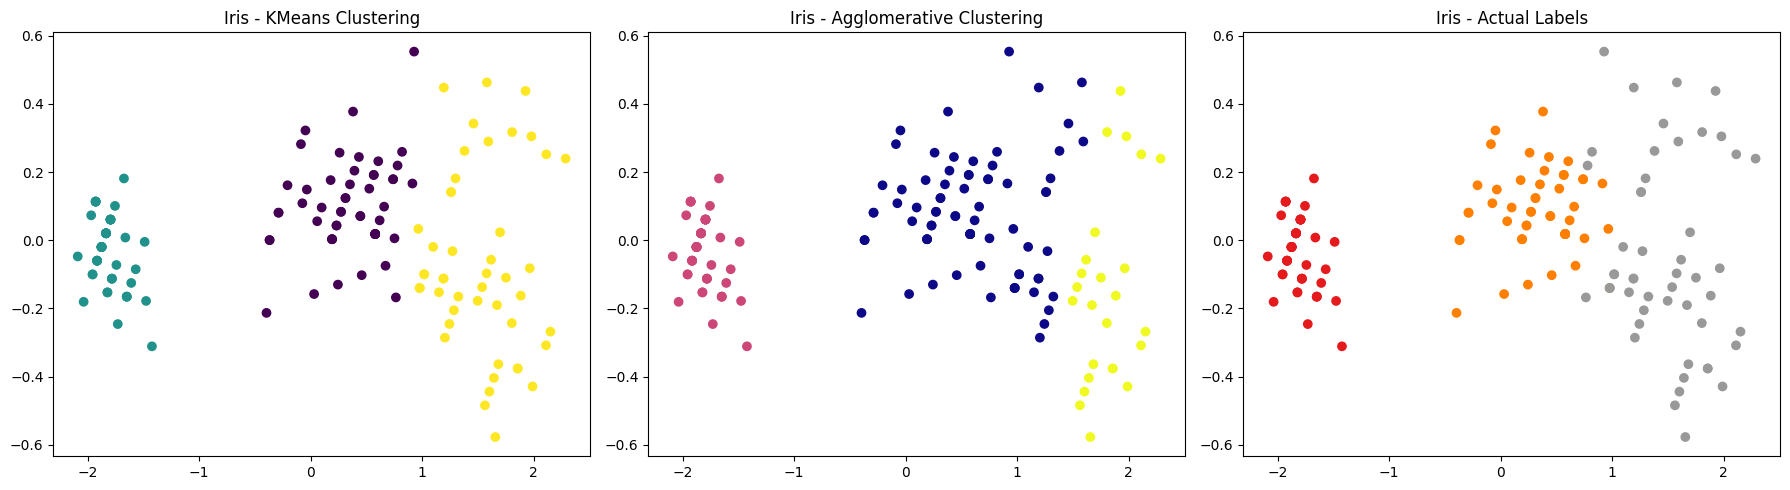

In [79]:
Kmeans_agglo(X_pcaed, 3)